
# Ciência da Computação

## Processamento Digital de Imagens - PDI
## Processamento de Imagens e Visão Computacional - PIVC
### Prof. Francisco Zampirolli




## Vídeos antigos

* [prática01-mctest (90min)](https://www.loom.com/share/c3a51459e1a344ca99f8742cef723e0f)

***

# Aula 07 - Prática de Visão Computacional - pasta 01

***




# Segmentar e decodificar códigos de barras e QRcode

Veja neste link um tutorial para decodificar código de barras:

http://www.sbfisica.org.br/fne/Vol12/Num2/a07.pdf

In [1]:
!pip install image > /dev/null

In [ ]:
#!pip install opencv-python==3.4.3.18
!pip install opencv-python==4.9.0.80 > /dev/null

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
print(cv2.__version__)

4.9.0


## Ler um arquivo pdf e gerar uma imagem

In [ ]:
if 1:
    !pip install pdf2image > /dev/null
    !apt-get install poppler-utils > /dev/null
    !pip install gdown > /dev/null
    !apt-get install -y poppler-utils > /dev/null
    #!brew install poppler # for mac
    # for windows http://blog.alivate.com.au/poppler-windows/

In [ ]:
url = 'https://drive.google.com/file/d/1MtOcXh6kJ1qbqCymI_P969e1znmQAdht/view?usp=sharing'
!gdown --id 1MtOcXh6kJ1qbqCymI_P969e1znmQAdht
file = "./test0.pdf"

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1MtOcXh6kJ1qbqCymI_P969e1znmQAdht
To: /content/test0.pdf
100% 655k/655k [00:00<00:00, 10.7MB/s]


In [ ]:
from pdf2image import convert_from_path
pages = convert_from_path(file, 200)
for i,page in enumerate(pages):
    page.save('test'+str(i).zfill(2)+'.png')

## Implemente abaixo a sua solução para segmentar o código de barras
### Obs. o código de barras pode estar em qualquer posição da folha


In [ ]:
def ero(f,B):
  Bh, Bw = B.shape
  Bcy, Bcx = Bh/2, Bw/2
  h,w = f.shape
  g = np.ones((h,w), dtype=int)*255

  # para varrer imagem na ordem raster
  for y in range(h): # para cada linha y
    for x in range(w): # para cada coluna x

      # para cada vizinho de (x,y)
      for by in range(Bh):
        for bx in range(Bw):
          viz_x = int(x + bx - Bcx + 0.5)
          viz_y = int(y + by - Bcy + 0.5)

          # verificar o domínion da image
          if 0 <= viz_x < w and 0 <= viz_y < h:

            # para calcular o mínino dos vizinhos
            if g[y,x] > f[viz_y,viz_x]:
              g[y,x] = f[viz_y,viz_x]

  return g

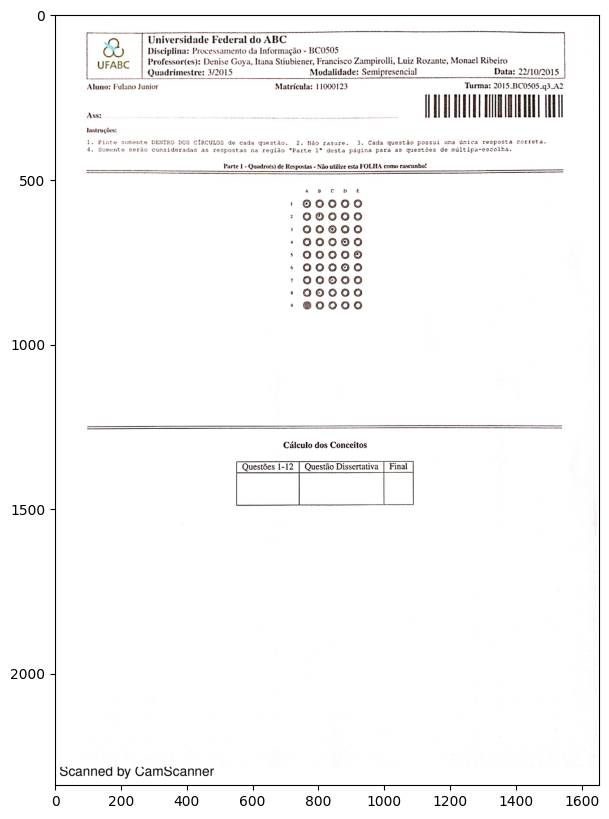

In [ ]:
# sua segmentação do código de barras
import cv2
img = cv2.imread("test00.png")
plt.figure(figsize=(17,10))
_=plt.imshow(img,"gray")

In [ ]:
img2 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img2 = img2[:500,:]
print(img2.shape)
b =np.array([[0]*19]*3,dtype=int)

print(b.shape)

# img3 = ero(img2,b) # MUIIIITO LENTO

(500, 1653)
(3, 19)


In [ ]:
# plt.figure(figsize=(17,10))
# _=plt.imshow(img3,"gray")

(1, 9)
[[1 1 1 1 1 1 1 1 1]]


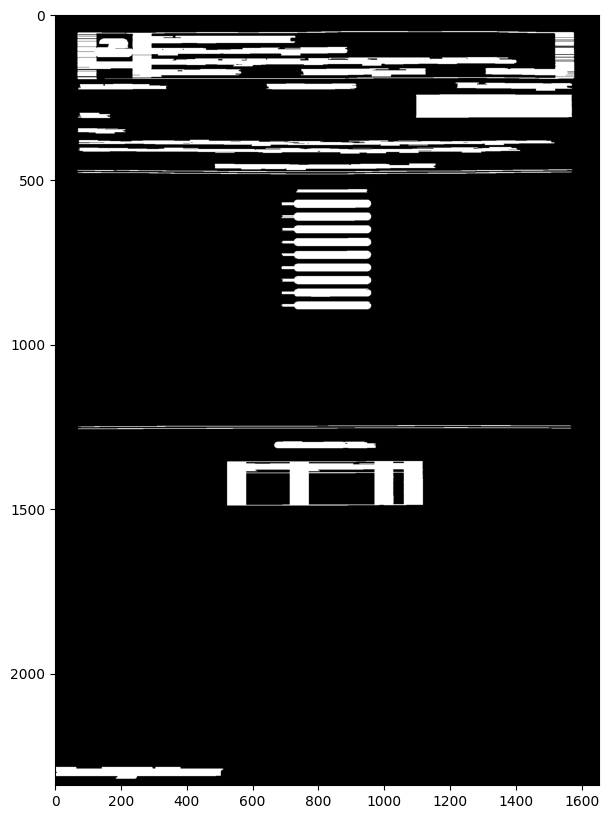

In [ ]:
# erosão usando cv2
img2 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
b =np.array([[1]*9]*1,dtype="uint8")
print(b.shape)
erosion = cv2.erode(img2,b,iterations = 7)
ret,thresh = cv2.threshold(erosion,100,255,cv2.THRESH_BINARY_INV)
plt.figure(figsize=(17,10))
_=plt.imshow(thresh,"gray")
print(b)

In [ ]:
imgIN = img.copy()
contours,_ = cv2.findContours(thresh, 1, 2)
print(len(contours))
retangulo = []
for cnt in contours:
  x,y,w,h = cv2.boundingRect(cnt)
  if 300<w<500 and 70<h<150:
    retangulo = [[x,y],[x+w,y+h]]
    cv2.rectangle(imgIN,(x,y),(x+w,y+h),(0,255,0),2)

79


[1095, 241] [1568, 312]


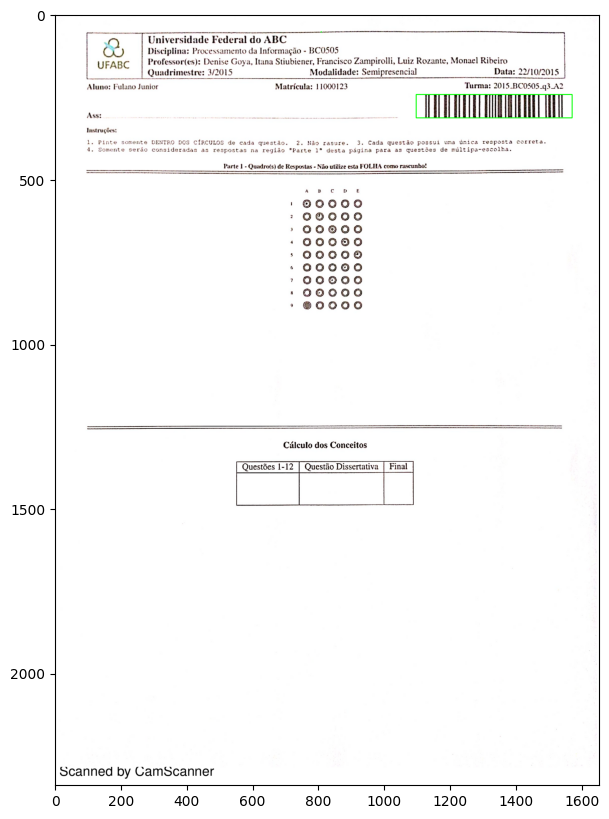

In [ ]:
p1, p2, = retangulo
print(p1,p2)
_=cv2.drawContours(imgIN, cnt, 3, (0,255,0), 3)
plt.figure(figsize=(17,10))
borda = 5
img5 = img2[p1[1]-borda:p2[1]+borda,p1[0]-borda:p2[0]+borda]
_=plt.imshow(imgIN)
#_=plt.imshow(img2[p1[1]-borda:p2[1]+borda,p1[0]-borda:p2[0]+borda],"gray")
#cv2.imwrite('mybarcode.png',img5)

In [ ]:
candidate = []
areaMax = 0
for contour in contours:
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.1*perimeter, True)
    if len(approx) == 4: # pego apenas os objetos com 4 lados
        approx = np.array(approx, dtype='float32').reshape(4,2)
        if (areaMax < cv2.contourArea(contour)): # acha a maior área
            areaMax = cv2.contourArea(contour)
            candidate = approx
print(candidate)

[[ 969. 1391.]
 [ 968. 1487.]
 [ 769. 1486.]
 [ 770. 1391.]]


In [ ]:
print(retangulo)

[[1095, 241], [1568, 312]]


## Para decodificar uma imagem de código de barras

In [ ]:
if 1:
    !pip install pyzbar > /dev/null
    !apt install libzbar0 > /dev/null

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1rArPDT4aUdoaXL1Yp4cIxKD2LLmcYuwz
To: /content/barcode.png
100% 13.9k/13.9k [00:00<00:00, 19.0MB/s]
[Decoded(data=b'0000000000055', type='EAN13', rect=Rect(left=5, top=6, width=320, height=50), polygon=[Point(x=5, y=7), Point(x=5, y=55), Point(x=325, y=56), Point(x=325, y=6)], quality=86, orientation='UP')]
0000000000055


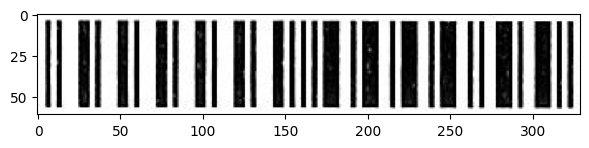

In [ ]:
from PIL import Image
import io
from pyzbar import pyzbar

url = 'https://drive.google.com/file/d/1rArPDT4aUdoaXL1Yp4cIxKD2LLmcYuwz/view?usp=sharing'
!gdown --id 1rArPDT4aUdoaXL1Yp4cIxKD2LLmcYuwz
file = "barcode.png"

image = cv2.imread(file)
plt.figure(figsize=(7,10))
_=plt.imshow(image,"gray")
barcode = pyzbar.decode(image)
print (barcode)
print (barcode[0].data.decode("utf-8"))

[Decoded(data=b'0000110001232', type='EAN13', rect=Rect(left=33, top=6, width=417, height=68), polygon=[Point(x=33, y=73), Point(x=248, y=74), Point(x=450, y=72), Point(x=450, y=62), Point(x=449, y=6), Point(x=34, y=7)], quality=84, orientation='UP')]
0000110001232


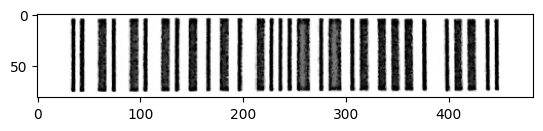

In [ ]:
_=plt.imshow(img5,"gray")
barcode = pyzbar.decode(img5)
print (barcode)
print (barcode[0].data.decode("utf-8"))

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1P32GAdvtPeYprN2NXePd25xIECyjsPdm
To: /content/barcode2.png
100% 18.7k/18.7k [00:00<00:00, 24.3MB/s]
[Decoded(data=b'0000210236145', type='EAN13', rect=Rect(left=5, top=8, width=309, height=55), polygon=[Point(x=5, y=15), Point(x=5, y=63), Point(x=314, y=62), Point(x=314, y=8), Point(x=163, y=8)], quality=97, orientation='UP')]
0000210236145


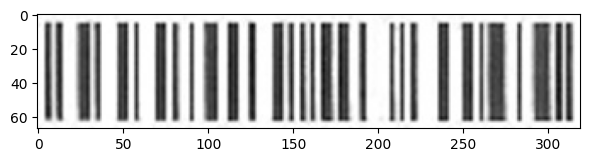

In [ ]:
url = 'https://drive.google.com/file/d/1P32GAdvtPeYprN2NXePd25xIECyjsPdm/view?usp=sharing'
!gdown --id 1P32GAdvtPeYprN2NXePd25xIECyjsPdm
file = "barcode2.png"

image = cv2.imread(file)
plt.figure(figsize=(7,10))
_=plt.imshow(image,"gray")
barcode = pyzbar.decode(image)
print (barcode)
print (barcode[0].data.decode("utf-8"))

# PARTE 2 - Segmentar e decodificar QRcode

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1f39paMYV4DkRSmNFj06uXBRimQHZf_ml
To: /content/extra02.qrcode.png
100% 389k/389k [00:00<00:00, 5.46MB/s]


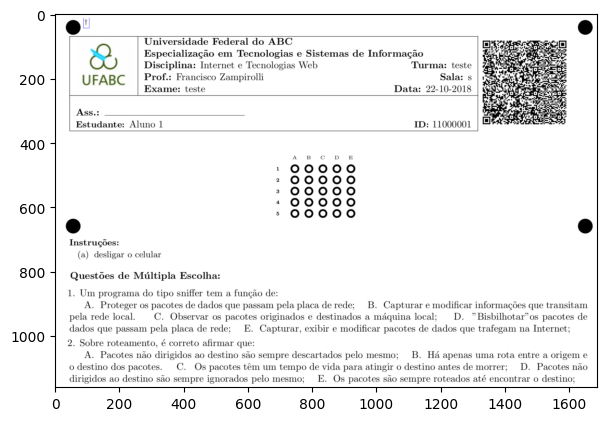

In [ ]:
url = 'https://drive.google.com/file/d/1f39paMYV4DkRSmNFj06uXBRimQHZf_ml/view?usp=sharing'
!gdown --id 1f39paMYV4DkRSmNFj06uXBRimQHZf_ml
file = "./extra02.qrcode.png"

img = cv2.imread(file)

plt.figure(figsize=(7,10))
_=plt.imshow(img,"gray")

(3, 3)


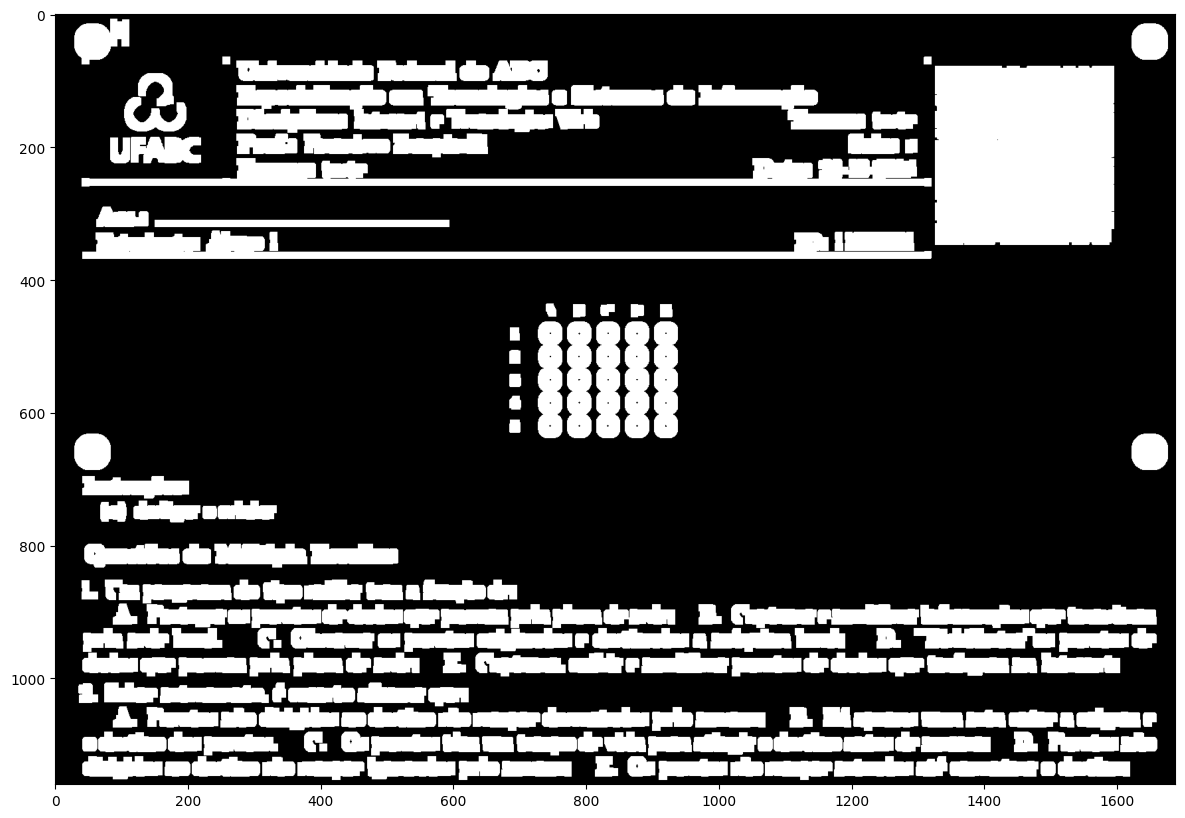

In [ ]:
img2 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
b =np.array([[1]*3]*3,dtype="uint8")
print(b.shape)
erosion = cv2.erode(img2,b,iterations = 5)
ret,thresh = cv2.threshold(erosion,100,255,cv2.THRESH_BINARY_INV)
plt.figure(figsize=(17,10))
_=plt.imshow(thresh,"gray")

In [ ]:
contours,_ = cv2.findContours(thresh, 1, 2)
print(len(contours))
retangulo = []
for cnt in contours:
  x,y,w,h = cv2.boundingRect(cnt)
  if 200<w<500 and 200<h<500:
    retangulo = [[x,y],[x+w,y+h]]
    cv2.rectangle(imgIN,(x,y),(x+w,y+h),(0,255,0),2)
    print(retangulo)

237
[[1325, 78], [1595, 348]]


[1325, 78] [1595, 348]


True

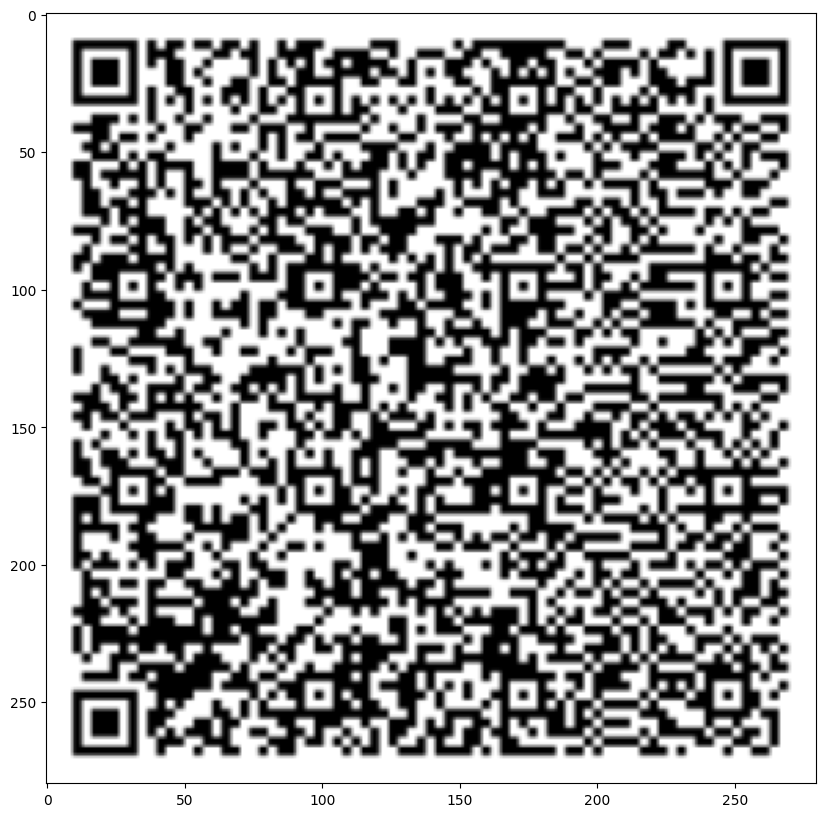

In [ ]:
p1, p2, = retangulo
print(p1,p2)
_=cv2.drawContours(imgIN, cnt, 3, (0,255,0), 3)
plt.figure(figsize=(17,10))
borda = 5
img5 = img2[p1[1]-borda:p2[1]+borda,p1[0]-borda:p2[0]+borda]
_=plt.imshow(img2[p1[1]-borda:p2[1]+borda,p1[0]-borda:p2[0]+borda],"gray")
cv2.imwrite('mybarcode.png',img5)

## Segmentar e decoficar de um pdf

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR
To: /content/extra02.qrcodeSeg.png
100% 356k/356k [00:00<00:00, 6.01MB/s]
[Decoded(data=b'446b6c4f51344d504934464e372e683051434855582e32707464544c63492f4662524a6d77757455494f6c6977317470654975332e789c3d89c10900310cc356b2ec140ebcff5e6d3e277d04523f8a52d0425d7aaadf53074f76c51979238ce29a9977f502314e2fa4011066', type='QRCODE', rect=Rect(left=13, top=21, width=595, height=596), polygon=[Point(x=13, y=614), Point(x=608, y=617), Point(x=606, y=21), Point(x=15, y=23)], quality=1, orientation='UP')]
446b6c4f51344d504934464e372e683051434855582e32707464544c63492f4662524a6d77757455494f6c6977317470654975332e789c3d89c10900310cc356b2ec140ebcff5e6d3e277d04523f8a52d0425d7aaadf53074f76c51979238ce29a9977

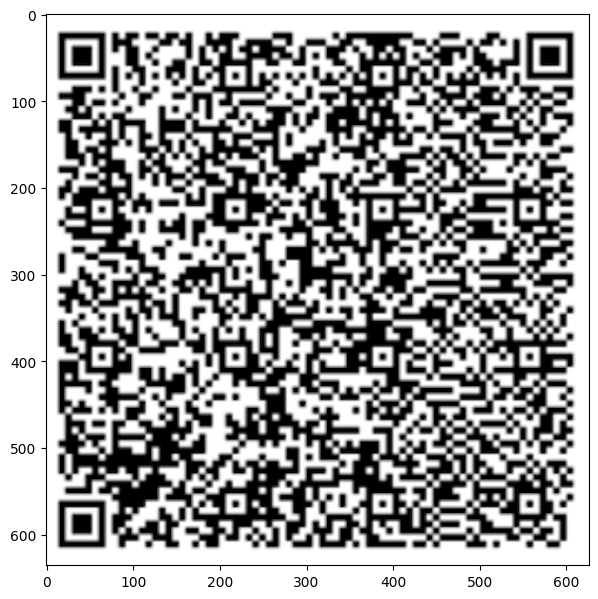

In [ ]:
url = 'https://drive.google.com/file/d/1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR/view?usp=sharing'
!gdown --id 1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR
file = "./extra02.qrcodeSeg.png"

image = cv2.imread(file)
plt.figure(figsize=(7,10))
_=plt.imshow(image,"gray")
barcode = pyzbar.decode(image)
print (barcode)
print (barcode[0].data.decode("utf-8"))

In [ ]:
barcode = pyzbar.decode(img5)
print (barcode)
print (barcode[0].data.decode("utf-8"))

[Decoded(data=b'446b6c4f51344d504934464e372e683051434855582e32707464544c63492f4662524a6d77757455494f6c6977317470654975332e789c3d89c10900310cc356b2ec140ebcff5e6d3e277d04523f8a52d0425d7aaadf53074f76c51979238ce29a9977f502314e2fa4011066', type='QRCODE', rect=Rect(left=9, top=9, width=260, height=261), polygon=[Point(x=9, y=10), Point(x=9, y=269), Point(x=269, y=270), Point(x=269, y=9)], quality=1, orientation='UP')]
446b6c4f51344d504934464e372e683051434855582e32707464544c63492f4662524a6d77757455494f6c6977317470654975332e789c3d89c10900310cc356b2ec140ebcff5e6d3e277d04523f8a52d0425d7aaadf53074f76c51979238ce29a9977f502314e2fa4011066


# PARTE 3. Fazer rotações aleatórias nas páginas contendo códigos de barras e QRcode

# PARTE 4. Segmentar e decodificar os códigos de barras e Qrcode nas imagens rotacionadas

# PARTE 5. Usar as implementações do MCTest

O MCTest é um software de código aberto disponível no [GitHub](https://github.com/fzampirolli/mctest). Para mais detalhes, ver [vision.ufabc.edu.br](http://vision.ufabc.edu.br).

In [ ]:
import requests
CVMCTest = requests.get("https://raw.githubusercontent.com/fzampirolli/mctest/master/exam/CVMCTest.py")
with open('CVMCTest.py', 'w') as writefile:
    writefile.write(CVMCTest.text)

In [ ]:
if 1:
  !pip install PyPDF2 > /dev/null
  !pip install bcrypt > /dev/null
  !pip install scikit-image > /dev/null

Remover em CVMCTest.py as linhas abaixo:

```
from django.http import HttpResponse, Http404
from django.utils.translation import gettext_lazy as _

from exam.UtilsLatex import Utils
from exam.models import Exam, StudentExam, StudentExamQuestion
from mctest.settings import BASE_DIR
from mctest.settings import webMCTest_FROM
from mctest.settings import webMCTest_PASS
from mctest.settings import webMCTest_SERVER
from student.models import Student
from topic.models import Question
````


In [ ]:
# remove linhas with "form django.", ...
!sed --in-place '/from django./d' CVMCTest.py
!sed --in-place '/from exam./d' CVMCTest.py
!sed --in-place '/from mctest./d' CVMCTest.py
!sed --in-place '/from student./d' CVMCTest.py
!sed --in-place '/from topic./d' CVMCTest.py
!sed --in-place '/from .models import VariationExam/d' CVMCTest.py

### Decodificação a partir da imagem no QRCode

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR
To: /content/extra02.qrcodeSeg.png
100% 356k/356k [00:00<00:00, 5.81MB/s]


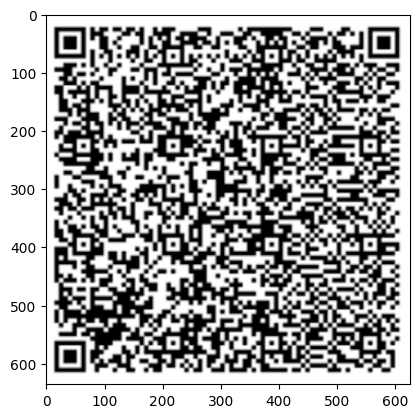

In [ ]:
import cv2
import matplotlib.pyplot as plt

url = 'https://drive.google.com/file/d/1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR/view?usp=sharing'
!gdown --id 1ZJObJD-tZvDc1aMU_rXwzhDJd5ShidaR
file = "./extra02.qrcodeSeg.png"

image = cv2.imread(file)
_=plt.imshow(image,"gray")

In [ ]:
#!pip install -U numpy==1.21.4

In [ ]:
!pip show pyarrow > /dev/null
!pip install --upgrade cudf-cu12 > /dev/null
!pip install skimage > /dev/null

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import CVMCTest

ss = CVMCTest.cvMCTest.decodeQRcode(image)
ss

{'date': '0',
 'idClassroom': '81',
 'idExam': '103',
 'idStudent': '11000001',
 'term': '2',
 'stylesheet': '1',
 'var1': '5',
 'var2': '0',
 'var3': '0',
 'var4': '0',
 'var5': '0',
 'text': '0',
 'answer': '5',
 'numquest': 5,
 'correct': '',
 'dbtext': '',
 'variations': '23124301',
 'variant': '23234021'}

### Decodificação a partir de um PDF com várias páginas

In [ ]:
url = 'https://drive.google.com/file/d/1a_qA2vz7J9o2E8Yrz8ztLqeB36DUyOvD/view?usp=sharing'
!gdown --id 1a_qA2vz7J9o2E8Yrz8ztLqeB36DUyOvD
file = "./extra02.qrcode.pdf"

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1a_qA2vz7J9o2E8Yrz8ztLqeB36DUyOvD
To: /content/extra02.qrcode.pdf
100% 155k/155k [00:00<00:00, 3.94MB/s]


In [ ]:
from pdf2image import convert_from_path

In [ ]:
pages = convert_from_path(file, 200)  # dpi 100=min 500=max
numPAGES = 0
MYFILES = 'extra02.qrcode'
for page in pages:
  myfile0 = MYFILES + '_p' + str(numPAGES) + '.png'
  page.save(myfile0)
  numPAGES += 1
pages.clear()

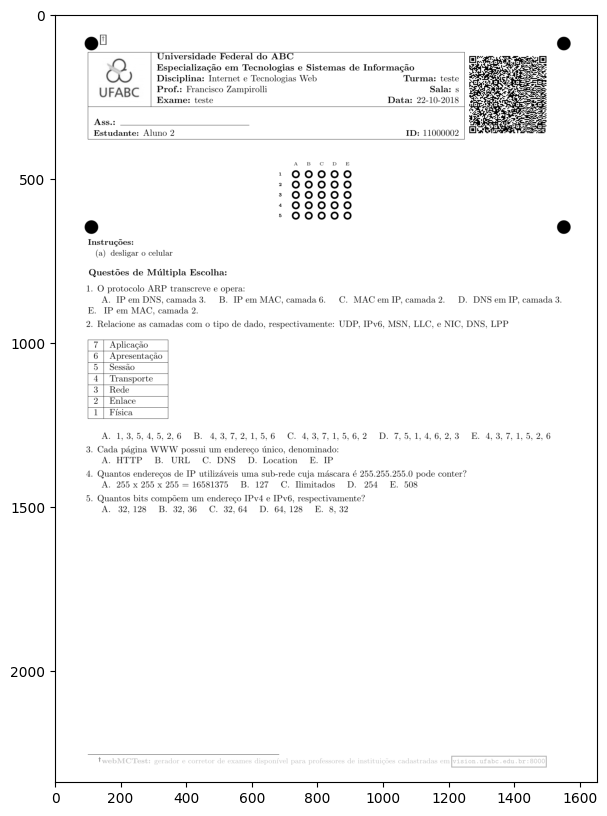

In [ ]:
img = cv2.imread(myfile0)
img = img0 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(7,10))
_=plt.imshow(img,"gray")

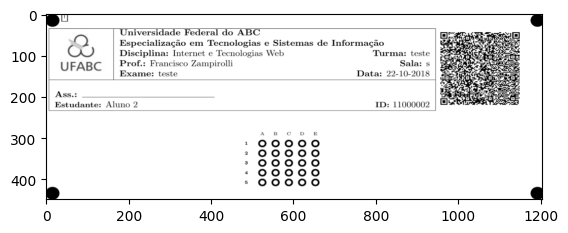

In [ ]:
import CVMCTest
countPage = 0
img2 = CVMCTest.cvMCTest.getAnswerArea(img, countPage)
_=plt.imshow(img2,"gray")

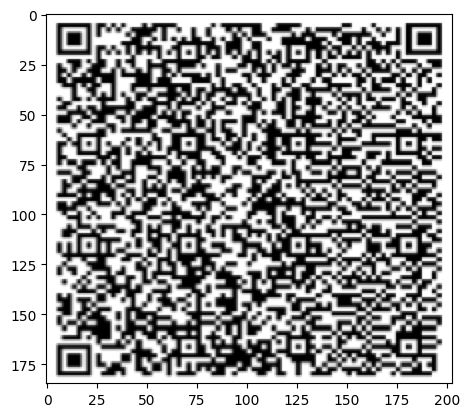

In [ ]:
imgQR = CVMCTest.cvMCTest.segmentQRcode(img2, countPage)
_=plt.imshow(imgQR,"gray")

In [ ]:
ss = CVMCTest.cvMCTest.decodeQRcode(imgQR)
ss

{'date': '0',
 'idClassroom': '81',
 'idExam': '103',
 'idStudent': '11000002',
 'term': '2',
 'stylesheet': '1',
 'var1': '5',
 'var2': '0',
 'var3': '0',
 'var4': '0',
 'var5': '0',
 'text': '0',
 'answer': '5',
 'numquest': 5,
 'correct': '',
 'dbtext': '',
 'variations': '22341230',
 'variant': '21510432'}

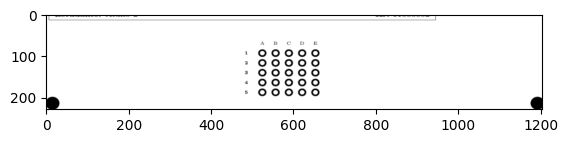

In [ ]:
img3 = img2[220:,:]
_=plt.imshow(img3,"gray")

4.9.0


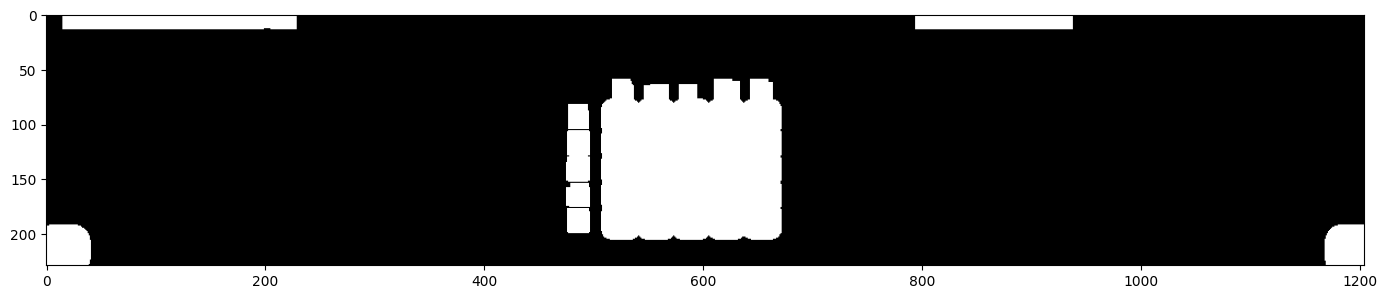

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
print(cv2.__version__)
b =np.ones((3,3),dtype="uint8")
erosion = cv2.erode(img3,b,iterations = 8)
ret,img4 = cv2.threshold(erosion,100,255,cv2.THRESH_BINARY_INV)
plt.figure(figsize=(17,10))
_=plt.imshow(img4,"gray")

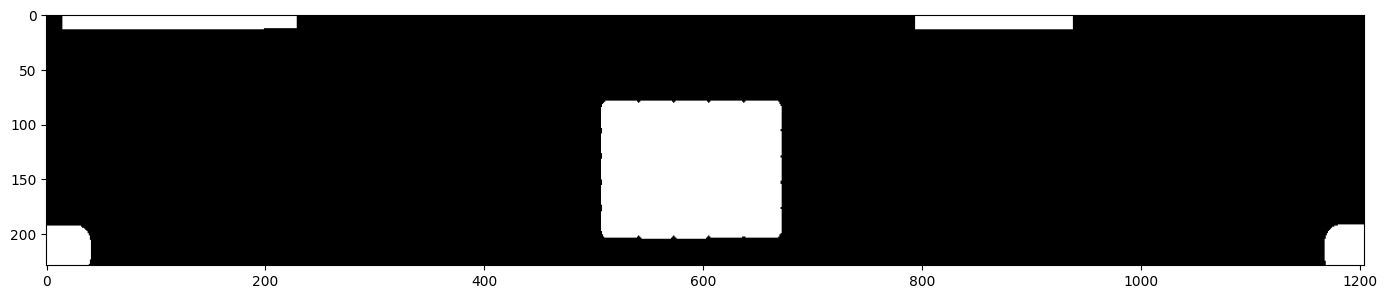

In [ ]:
b =np.ones((1,3),dtype="uint8")
img5 = cv2.erode(img4,b,iterations = 13)
img6 = cv2.dilate(img5,b,iterations = 13)
plt.figure(figsize=(17,10))
_=plt.imshow(img6,"gray")

5
(507, 79, 165, 126) 507


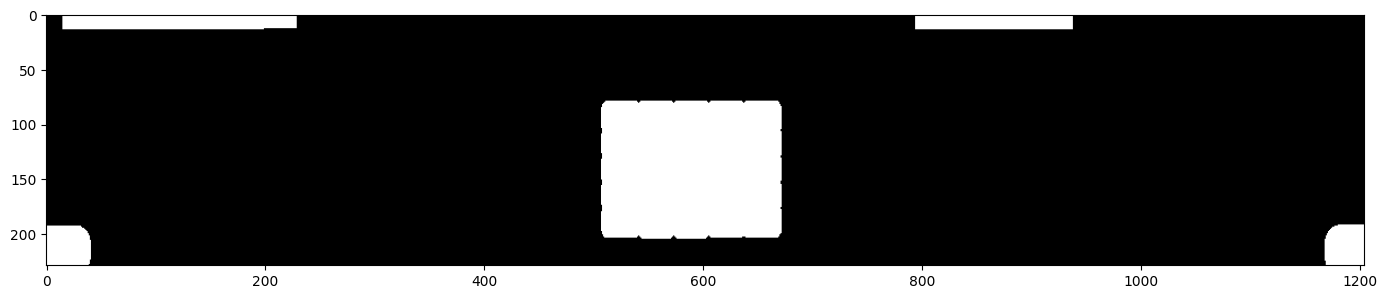

In [ ]:
imgIN = img6.copy()
imgIN = cv2.cvtColor(imgIN, cv2.COLOR_GRAY2RGB)
contours,_ = cv2.findContours(img6, 1, 2)
print(len(contours))
retangulo = []

c = max(contours, key = cv2.contourArea)
r = cv2.boundingRect(c)
print(r,r[0])

plt.figure(figsize=(17,10))
_=plt.imshow(imgIN,"gray")

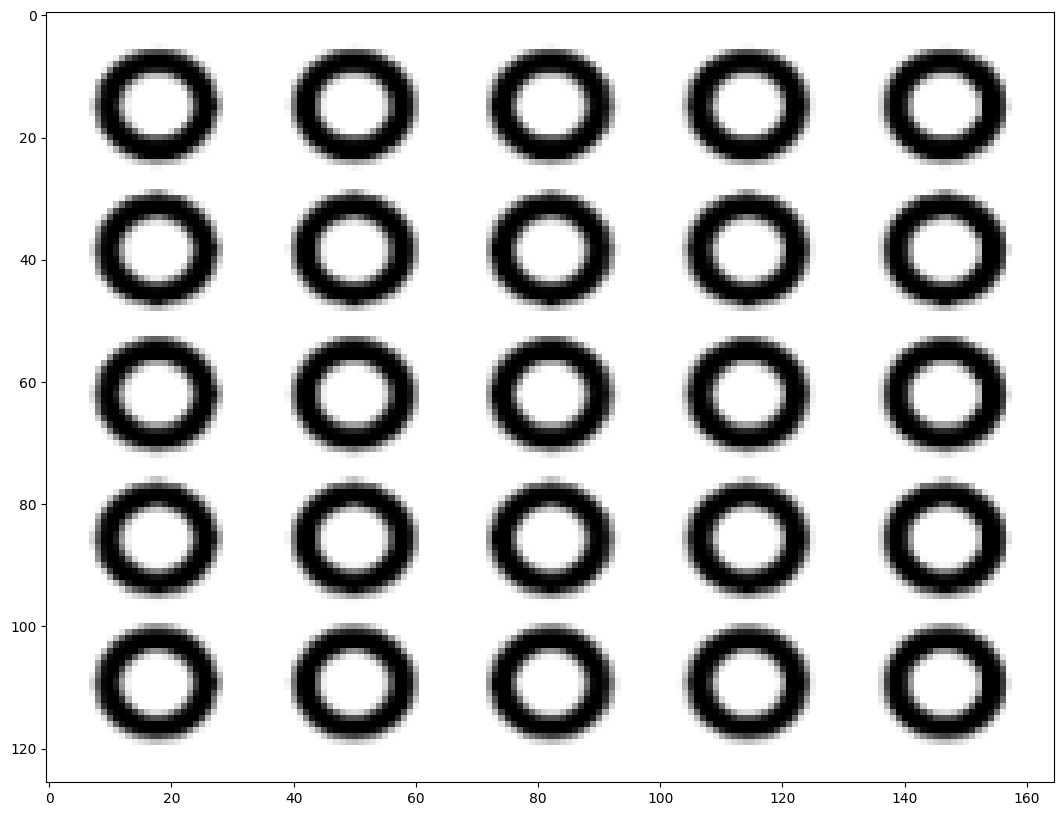

In [ ]:
plt.figure(figsize=(17,10))
borda = 5
img5 = img3[r[1]:r[1]+r[3], r[0]:r[0]+r[2]]
_=plt.imshow(img5,"gray")

In [ ]:
myFlagArea, qr = CVMCTest.cvMCTest.getQRCode(img, countPage)
myFlagArea, qr

(True,
 {'date': '0',
  'idClassroom': '81',
  'idExam': '103',
  'idStudent': '11000002',
  'term': '2',
  'stylesheet': '1',
  'var1': '5',
  'var2': '0',
  'var3': '0',
  'var4': '0',
  'var5': '0',
  'text': '0',
  'answer': '5',
  'numquest': 5,
  'correct': '',
  'dbtext': '',
  'variations': '22341230',
  'variant': '21510432'})

In [ ]:
rectSquares = CVMCTest.cvMCTest.findSquares(qr,img2, countPage)
rectSquares

[[[296, 508], [430, 674]]]

Após linha 673 de https://github.com/fzampirolli/mctest/blob/master/exam/views.py

In [ ]:
testAnswers = []
if myFlagArea:

  for countSquare in range(len(rectSquares)):
      p1, p2 = rectSquares[countSquare]


      if True:
          imgQi = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
          [NUM_COLUMNS, img] = CVMCTest.cvMCTest.setColumns(imgQi, countPage, countSquare)
          [NUM_LINES, img] = CVMCTest.cvMCTest.setLines(imgQi, countPage, countSquare)
          NUM_RESPOSTAS = NUM_COLUMNS
          NUM_QUESTOES = NUM_LINES

      imgQiNC = CVMCTest.cvMCTest.imgAnswers[p1[0]:p2[0], p1[1]:p2[1]]
      testAnswers.append(CVMCTest.cvMCTest.segmentAnswers([imgQi, imgQiNC], countPage, countSquare, NUM_QUESTOES, qr))

  qr = CVMCTest.cvMCTest.setAnswarsOneLine(testAnswers, qr)  # deixa as respostas de cada quadro em uma linha
qr['answers']

'0,0,0,0,0'